# Orbital Data Center: Levelized Cost of Compute (LCOC) Model

**Project:** Class analysis of whether passive radiative cooling can offset embodied launch energy and radiator mass costs for an orbital data center (ODC).

**Method:** First-principles sizing of PV array and radiator → mass and cost budget → LCOC via Nøland et al. (2024) Eq. 1.

**Notebook outline:**
1. Imports & global style
2. All input parameters (single source of truth)
3. Physical sizing functions
4. LCOC calculation functions
5. Terrestrial DC baseline
6. Time projection (2026–2045) with learning rates
7. Visualizations
   - 7a. LCOC by scenario — stacked bar (2026 baseline)
   - 7b. LCOC vs time — shaded scenario bands (ODC & TDC)
   - 7c. ODC/TDC ratio over time
   - 7d. Tornado plot — parameter sensitivity
   - 7e. LCOC vs Launch Cost — baseline sweep with TDC reference
8. Summary table

---
## 1. Imports & Global Style

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from dataclasses import dataclass, field, replace
from typing import Dict, List, Optional

# ── Global plot style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#444",
    "axes.linewidth": 0.9,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.7,
    "legend.framealpha": 0.92,
    "legend.edgecolor": "#ccc",
    "font.family": "DejaVu Sans",
})

PALETTE = {
    "Optimistic":  "#2ecc71",   # green
    "Nominal":     "#3498db",   # blue
    "Pessimistic": "#e74c3c",   # red
    "TDC":         "#2c3e50",   # near-black
    "Hardware":    "#5b8dee",
    "Launch":      "#e74c3c",
    "Data":        "#f39c12",
}

print("Style loaded.")

Style loaded.


---
## 2. All Input Parameters — Single Source of Truth

Edit the tables below to change any assumption.  
Everything downstream recomputes automatically.

In [2]:
# ── Physical / architectural constants ────────────────────────────────────────
SIGMA          = 5.67e-8   # W m⁻² K⁻⁴  Stefan-Boltzmann
I_SUN          = 1367      # W/m²  solar constant
T_EARTH_EFF    = 255       # K     effective Earth IR temperature
EARTH_ALBEDO   = 0.30      # –     Bond albedo

# ── Fixed architecture parameters ─────────────────────────────────────────────
Q_COMPUTE          = 100e6     # W    compute payload power
LIFETIME_YR        = 15        # years spacecraft lifetime
REFRESH_INTERVAL   = 5         # years IT compute refresh
HOURS_PER_YEAR     = 8765.8
SECONDS_PER_YEAR   = HOURS_PER_YEAR * 3600

T_RAD_C            = 80        # °C  radiator temperature  (fixed)
T_CHIP_C           = 85        # °C  chip junction temperature (fixed)
ARM_ANGLE_DEG      = 45        # °   radiator arm angle from vertical (fixed)
EPS_PV_BACK        = 0.85      # –   PV back-side IR emissivity (fixed)

DATA_MASS_PER_DROP = 1000      # kg/drop
DATA_DROPS_PER_YR  = 2         # drops/yr
DATA_FIXED_COST    = 1.0e6     # $/drop  (nominal; scaled ×0.5/×2 in scenarios)

# ── Terrestrial DC baseline (Nøland et al. Table 5) ───────────────────────────
TDC_CAPEX_PER_KW   = 10_000   # $/kW  capital cost
TDC_OPEX_FRAC      = 0.10     # –     annual OPEX fraction of CAPEX
TDC_PUE            = 1.12     # –     power usage effectiveness
TDC_ELEC_PER_MWH   = 150      # $/MWh electricity price
TDC_WACC           = 0.10     # –     discount rate
TDC_LIFETIME       = 15       # years

print("Constants loaded.")

Constants loaded.


In [3]:
# ── Variable parameters — three scenarios ─────────────────────────────────────
#
#  All scenario-specific values live in this one table.
#  Columns: [Optimistic, Nominal, Pessimistic]
#  Source paper: Nøland et al. 2024; LCOC Paper

PARAM_TABLE = {
    # label                         optimistic   nominal    pessimistic  units
    "gamma_PFLOPS_per_kW":          (6.0,         1.5,       0.107),   # PFLOPS/kW
    "launch_cost_per_kg":           (300,         1500,      2500),    # $/kg
    "pv_eff_BOL":                   (0.34,        0.32,      0.30),    # –
    "pv_derating":                  (0.90,        0.85,      0.75),    # –
    "pv_areal_mass":                (1.5,         3.0,       5.0),     # kg/m²
    "pv_areal_cost":                (1000,        2500,      5000),    # $/m²
    "rad_areal_mass":               (3.0,         5.0,       8.0),     # kg/m²
    "rad_areal_cost":               (5000,        10000,     20000),   # $/m²
    "it_mass_density":              (15000,       25000,     40000),   # kg/MW
    "it_cost_per_MW":               (5e6,         10e6,      20e6),    # $/MW
    "F_PV":                         (0.05,        0.15,      0.25),    # –
    "T_PV_C":                       (60,          80,        100),     # °C
    "alpha_solar_rad":              (0.04,        0.05,      0.06),    # –
    "eps_IR":                       (0.92,        0.90,      0.88),    # –
    "discount_rate":                (0.05,        0.08,      0.12),    # –
    "F_earth":                      (0.07,        0.10,      0.13),    # –
}

# Learning rates for the 2026-2045 projection
LEARNING_RATES = {
    "launch":       0.12,    # 12%/yr decline  — SpaceX historical trajectory
    "pv_cost":      0.06,    # 6%/yr decline   — space-grade solar
    "rad_cost":     0.03,    # 3%/yr decline   — mature aerospace hardware
    "it_cost":      0.08,    # 8%/yr decline   — cost-per-FLOP improvement
    "gamma_growth": 0.15,    # 15%/yr growth   — AI hardware (PFLOPS/kW)
    "pv_eff_pp":    0.003,   # +0.3 pp/yr abs  — approaching theoretical limit
    "terr_capex":   0.02,    # 2%/yr decline   — mature TDC tech
    "elec_price":   0.0,     # flat real terms
}

START_YEAR, END_YEAR = 2026, 2045

print("Parameter table loaded.")
print(f"Variable parameters: {len(PARAM_TABLE)}")
print(f"Learning rates defined: {len(LEARNING_RATES)}")

Parameter table loaded.
Variable parameters: 16
Learning rates defined: 8


---
## 3. Scenario Construction & Physical Sizing

In [4]:
@dataclass
class Scenario:
    name: str
    gamma_PFLOPS_per_kW: float
    launch_cost_per_kg:  float
    pv_eff_BOL:          float
    pv_derating:         float
    pv_areal_mass:       float
    pv_areal_cost:       float
    rad_areal_mass:      float
    rad_areal_cost:      float
    it_mass_density:     float
    it_cost_per_MW:      float
    F_PV:                float
    T_PV_C:              float
    alpha_solar_rad:     float
    eps_IR:              float
    discount_rate:       float
    F_earth:             float
    # Fixed fields (inherited from global constants)
    T_rad_C:             float = field(default_factory=lambda: T_RAD_C)
    T_chip_C:            float = field(default_factory=lambda: T_CHIP_C)
    arm_angle_deg:       float = field(default_factory=lambda: ARM_ANGLE_DEG)
    eps_PV_back:         float = field(default_factory=lambda: EPS_PV_BACK)
    data_mass_per_drop:  float = field(default_factory=lambda: DATA_MASS_PER_DROP)
    data_drops_per_year: float = field(default_factory=lambda: DATA_DROPS_PER_YR)
    data_fixed_cost:     float = field(default_factory=lambda: DATA_FIXED_COST)


def make_scenario(name: str, col_idx: int) -> Scenario:
    """Build a Scenario from PARAM_TABLE column col_idx (0=opt, 1=nom, 2=pes)."""
    params = {k: v[col_idx] for k, v in PARAM_TABLE.items()}
    # Scale data fixed cost with scenario (0.5M / 1M / 2M)
    params["data_fixed_cost"] = DATA_FIXED_COST * [0.5, 1.0, 2.0][col_idx]
    return Scenario(name=name, **params)


OPTIMISTIC  = make_scenario("Optimistic",  0)
NOMINAL     = make_scenario("Nominal",     1)
PESSIMISTIC = make_scenario("Pessimistic", 2)
SCENARIOS   = [OPTIMISTIC, NOMINAL, PESSIMISTIC]


# ── Physical sizing ────────────────────────────────────────────────────────────
def size_pv_array(s: Scenario) -> float:
    """Required PV area [m²] to power Q_COMPUTE."""
    return Q_COMPUTE / (s.pv_eff_BOL * s.pv_derating * I_SUN)


def size_radiator(s: Scenario, verbose: bool = False) -> float:
    """Required radiator area [m²] to reject Q_COMPUTE."""
    T_rad = s.T_rad_C + 273.15
    T_PV  = s.T_PV_C  + 273.15
    theta = np.radians(s.arm_angle_deg)
    P_emit    = 2 * s.eps_IR * SIGMA * T_rad**4
    P_solar   = s.alpha_solar_rad * I_SUN * np.cos(theta)
    P_albedo  = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
    P_earth   = s.eps_IR * SIGMA * T_EARTH_EFF**4 * s.F_earth
    P_PV_rad  = s.eps_IR * s.eps_PV_back * SIGMA * T_PV**4 * s.F_PV
    P_net     = P_emit - P_solar - P_albedo - P_earth - P_PV_rad
    if P_net <= 0:
        raise ValueError(f"Net radiator cooling non-positive ({P_net:.1f} W/m²). Check scenario parameters.")
    if verbose:
        print(f"  Emit: +{P_emit:.0f}  Solar: -{P_solar:.1f}  "
              f"Albedo: -{P_albedo:.1f}  EarthIR: -{P_earth:.1f}  "
              f"PV-IR: -{P_PV_rad:.1f}  Net: +{P_net:.0f} W/m²")
    return Q_COMPUTE / P_net


def mass_budget(s: Scenario) -> Dict:
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    m_PV  = A_PV  * s.pv_areal_mass
    m_rad = A_rad * s.rad_areal_mass
    m_IT  = (Q_COMPUTE / 1e6) * s.it_mass_density
    return {
        "PV":       m_PV,
        "Radiator": m_rad,
        "IT":       m_IT,
        "Total":    m_PV + m_rad + m_IT,
        "A_PV":     A_PV,
        "A_rad":    A_rad,
    }


# Quick sanity print
print(f"{'':12s}  {'A_PV (m²)':>12s}  {'A_rad (m²)':>12s}  {'Mass (t)':>10s}")
for s in SCENARIOS:
    mb = mass_budget(s)
    print(f"{s.name:12s}  {mb['A_PV']:>12,.0f}  {mb['A_rad']:>12,.0f}  {mb['Total']/1000:>10,.1f}")

                 A_PV (m²)    A_rad (m²)    Mass (t)
Optimistic         239,062        64,929     2,053.4
Nominal            268,944        70,708     3,660.4
Pessimistic        325,124        79,494     6,261.6


---
## 4. LCOC Calculation

Follows Nøland et al. (2024) Eq. 1.  With $\alpha p k t = 0$ (no electricity cost) and $dc = 0$ (no OPEX):

$$\text{LCOC} = \frac{\sum_i \text{cost}_i / (1+r)^i}{\sum_i \gamma k t / (1+r)^i}$$

In [5]:
def annual_eflop(s: Scenario, k_load: float = 1.0) -> float:
    """Annual compute output [EFLOP/year].  γ in PFLOPS/kW = PFLOP/s/kW."""
    return (Q_COMPUTE / 1000) * s.gamma_PFLOPS_per_kW / 1000 * SECONDS_PER_YEAR * k_load


def build_cash_flows(s: Scenario) -> Dict[str, np.ndarray]:
    """Return dict of cost arrays over LIFETIME_YR years."""
    mb = mass_budget(s)
    cost_PV   = mb["A_PV"]  * s.pv_areal_cost
    cost_rad  = mb["A_rad"] * s.rad_areal_cost
    cost_IT   = (Q_COMPUTE / 1e6) * s.it_cost_per_MW
    cost_drop = s.data_fixed_cost + s.data_mass_per_drop * s.launch_cost_per_kg

    hardware = np.zeros(LIFETIME_YR)
    launch   = np.zeros(LIFETIME_YR)
    data     = np.zeros(LIFETIME_YR)

    hardware[0] = cost_PV + cost_rad + cost_IT
    launch[0]   = mb["Total"] * s.launch_cost_per_kg

    for ry in range(REFRESH_INTERVAL, LIFETIME_YR, REFRESH_INTERVAL):
        hardware[ry] += cost_IT
        launch[ry]   += mb["IT"] * s.launch_cost_per_kg

    data[:] = cost_drop * s.data_drops_per_year

    return {"hardware": hardware, "launch": launch, "data": data,
            "total": hardware + launch + data}


def calculate_lcoc(s: Scenario) -> Dict:
    """Return LCOC ($/EFLOP) and cost breakdown for scenario s."""
    cf      = build_cash_flows(s)
    years   = np.arange(LIFETIME_YR)
    compute = np.full(LIFETIME_YR, annual_eflop(s))
    disc    = 1.0 / (1 + s.discount_rate) ** years

    npv_cost    = (cf["total"] * disc).sum()
    npv_compute = (compute * disc).sum()
    lcoc        = npv_cost / npv_compute

    breakdown = {
        cat: (cf[cat.lower()] * disc).sum() / npv_compute
        for cat in ["Hardware", "Launch", "Data"]
    }
    return {"lcoc": lcoc, "breakdown": breakdown, "npv_cost": npv_cost}


results = {}
print(f"{'Scenario':12s}  {'γ (PFLOPS/kW)':>14s}  {'LCOC ($/EFLOP)':>16s}  {'NPV ($B)':>10s}")
print("-" * 60)
for s in SCENARIOS:
    results[s.name] = calculate_lcoc(s)
    r = results[s.name]
    print(f"{s.name:12s}  {s.gamma_PFLOPS_per_kW:>14.3f}  "
          f"${r['lcoc']:>14.4f}  {r['npv_cost']/1e9:>9.2f}")
    for cat, val in r["breakdown"].items():
        print(f"  └ {cat:10s} ${val:.4f}/EFLOP")

Scenario       γ (PFLOPS/kW)    LCOC ($/EFLOP)    NPV ($B)
------------------------------------------------------------
Optimistic             6.000  $        0.0147       3.02
  └ Hardware   $0.0085/EFLOP
  └ Launch     $0.0060/EFLOP
  └ Data       $0.0001/EFLOP
Nominal                1.500  $        0.3051      13.35
  └ Hardware   $0.0805/EFLOP
  └ Launch     $0.2235/EFLOP
  └ Data       $0.0011/EFLOP
Pessimistic            0.107  $       12.2727      31.61
  └ Hardware   $2.7155/EFLOP
  └ Launch     $9.5305/EFLOP
  └ Data       $0.0267/EFLOP


---
## 5. Terrestrial DC Baseline

In [6]:
def terrestrial_lcoc(
    gamma_PFLOPS_per_kW: float,
    c_per_kW:    float = TDC_CAPEX_PER_KW,
    d_frac:      float = TDC_OPEX_FRAC,
    alpha_PUE:   float = TDC_PUE,
    p_per_MWh:   float = TDC_ELEC_PER_MWH,
    r_wacc:      float = TDC_WACC,
    n_years:     int   = TDC_LIFETIME,
    k_load:      float = 1.0,
) -> float:
    """Nøland et al. 2024 Eq. 1 — returns terrestrial LCOC in $/EFLOP."""
    annual_elec    = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_opex    = d_frac * c_per_kW
    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    df             = np.array([1 / (1 + r_wacc)**i for i in range(n_years)])
    npv_costs      = c_per_kW + ((annual_elec + annual_opex) * df).sum()
    npv_compute    = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000   # $/PFLOP → $/EFLOP


# Verify vs published $1.16/EFLOP
verify = terrestrial_lcoc(0.1)
print(f"Verification @ γ=0.1: ${verify:.3f}/EFLOP  (paper says $1.16) {'✓' if abs(verify-1.16)<0.05 else '⚠'}")

terr = {}
for s in SCENARIOS:
    terr[s.name] = terrestrial_lcoc(s.gamma_PFLOPS_per_kW)
    print(f"TDC @ γ={s.gamma_PFLOPS_per_kW:<6.3f} ({s.name:12s}): ${terr[s.name]:.4f}/EFLOP")

Verification @ γ=0.1: $1.162/EFLOP  (paper says $1.16) ✓
TDC @ γ=6.000  (Optimistic  ): $0.0194/EFLOP
TDC @ γ=1.500  (Nominal     ): $0.0775/EFLOP
TDC @ γ=0.107  (Pessimistic ): $1.0863/EFLOP


---
## 6. Time Projection 2026–2045

In [7]:
def evolve_scenario(s_base: Scenario, year_offset: int) -> Scenario:
    """Return Scenario representing s_base evolved `year_offset` years forward."""
    lr = LEARNING_RATES
    return replace(
        s_base,
        gamma_PFLOPS_per_kW = s_base.gamma_PFLOPS_per_kW * (1 + lr["gamma_growth"])**year_offset,
        launch_cost_per_kg  = s_base.launch_cost_per_kg  * (1 - lr["launch"])**year_offset,
        pv_areal_cost       = s_base.pv_areal_cost       * (1 - lr["pv_cost"])**year_offset,
        rad_areal_cost      = s_base.rad_areal_cost      * (1 - lr["rad_cost"])**year_offset,
        it_cost_per_MW      = s_base.it_cost_per_MW      * (1 - lr["it_cost"])**year_offset,
        pv_eff_BOL          = min(0.40, s_base.pv_eff_BOL + lr["pv_eff_pp"] * year_offset),
    )


def terrestrial_evolved(gamma_baseline: float, year_offset: int) -> float:
    gamma_t  = gamma_baseline * (1 + LEARNING_RATES["gamma_growth"])**year_offset
    capex_t  = TDC_CAPEX_PER_KW * (1 - LEARNING_RATES["terr_capex"])**year_offset
    return terrestrial_lcoc(gamma_t, c_per_kW=capex_t)


years_calendar = np.arange(START_YEAR, END_YEAR + 1)
year_offsets   = years_calendar - START_YEAR

lcoc_odc = {s.name: np.array([calculate_lcoc(evolve_scenario(s, yo))["lcoc"]
                               for yo in year_offsets]) for s in SCENARIOS}
lcoc_tdc = {s.name: np.array([terrestrial_evolved(s.gamma_PFLOPS_per_kW, yo)
                               for yo in year_offsets]) for s in SCENARIOS}

# Summary table
print(f"{'Scenario':12s}  {'Year':>6s}  {'ODC $/EFLOP':>13s}  {'TDC $/EFLOP':>13s}  {'Ratio':>7s}")
print("-" * 62)
for s in SCENARIOS:
    for label, idx in [("2026", 0), ("2035", 9), ("2045", 19)]:
        odc = lcoc_odc[s.name][idx]
        tdc = lcoc_tdc[s.name][idx]
        print(f"{s.name:12s}  {label:>6s}  ${odc:>11.4f}  ${tdc:>11.4f}  {odc/tdc:>6.2f}x")

Scenario        Year    ODC $/EFLOP    TDC $/EFLOP    Ratio
--------------------------------------------------------------
Optimistic      2026  $     0.0147  $     0.0194    0.76x
Optimistic      2035  $     0.0019  $     0.0050    0.37x
Optimistic      2045  $     0.0002  $     0.0011    0.19x
Nominal         2026  $     0.3051  $     0.0775    3.94x
Nominal         2035  $     0.0325  $     0.0198    1.64x
Nominal         2045  $     0.0030  $     0.0044    0.68x
Pessimistic     2026  $    12.2727  $     1.0863   11.30x
Pessimistic     2035  $     1.2750  $     0.2781    4.59x
Pessimistic     2045  $     0.1153  $     0.0618    1.87x


---
## 7. Visualizations

### 7a. LCOC by Scenario — Stacked Bar (2026 Baseline)

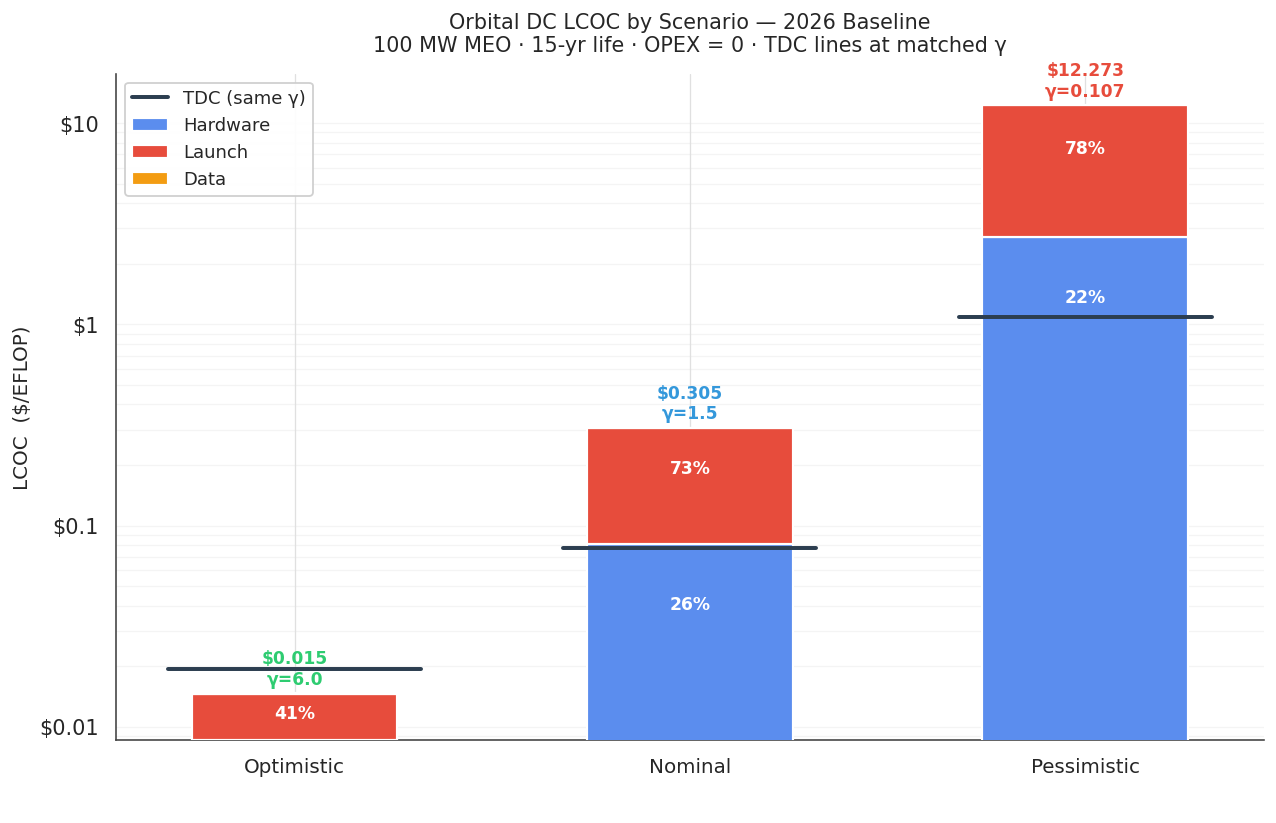

In [8]:
fig, ax = plt.subplots(figsize=(10, 6.5))

scenario_names = [s.name for s in SCENARIOS]
categories     = ["Hardware", "Launch", "Data"]
bar_colors     = [PALETTE[c] for c in categories]
x              = np.arange(len(scenario_names))
bar_w          = 0.52

bottoms = np.zeros(len(scenario_names))
for cat, color in zip(categories, bar_colors):
    vals = np.array([results[n]["breakdown"][cat] for n in scenario_names])
    bars = ax.bar(x, vals, bottom=bottoms, label=cat,
                  color=color, edgecolor="white", linewidth=1.2, width=bar_w,
                  zorder=3)
    # pct label inside bar segment if tall enough
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        total = results[scenario_names[i]]["lcoc"]
        pct   = v / total * 100
        if pct > 8:
            ax.text(x[i], b + v / 2, f"{pct:.0f}%",
                    ha="center", va="center", fontsize=9.5,
                    color="white", fontweight="bold", zorder=4)
    bottoms += vals

# Total label above each bar
for i, s in enumerate(SCENARIOS):
    total = results[s.name]["lcoc"]
    ax.text(x[i], total * 1.06,
            f"${total:.3f}\nγ={s.gamma_PFLOPS_per_kW}",
            ha="center", va="bottom", fontsize=9.5, fontweight="bold",
            color=PALETTE[s.name])

# TDC reference ticks
for i, s in enumerate(SCENARIOS):
    tdc_val = terr[s.name]
    ax.plot([x[i] - bar_w/2 - 0.06, x[i] + bar_w/2 + 0.06],
            [tdc_val, tdc_val],
            color=PALETTE["TDC"], linewidth=2.2, solid_capstyle="round",
            label="TDC (same γ)" if i == 0 else None, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(scenario_names, fontsize=11)
ax.set_ylabel("LCOC  ($/EFLOP)", fontsize=11)
ax.set_title("Orbital DC LCOC by Scenario — 2026 Baseline\n"
             "100 MW MEO · 15-yr life · OPEX = 0 · TDC lines at matched γ",
             fontsize=11.5, pad=12)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y:g}"))
ax.legend(loc="upper left", fontsize=10, framealpha=0.92)
ax.grid(axis="y", which="both", alpha=0.35, zorder=0)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=False)
plt.tight_layout()
plt.savefig("/home/claude/fig_lcoc_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### 7b. LCOC vs Time — Shaded Scenario Bands (ODC & TDC)

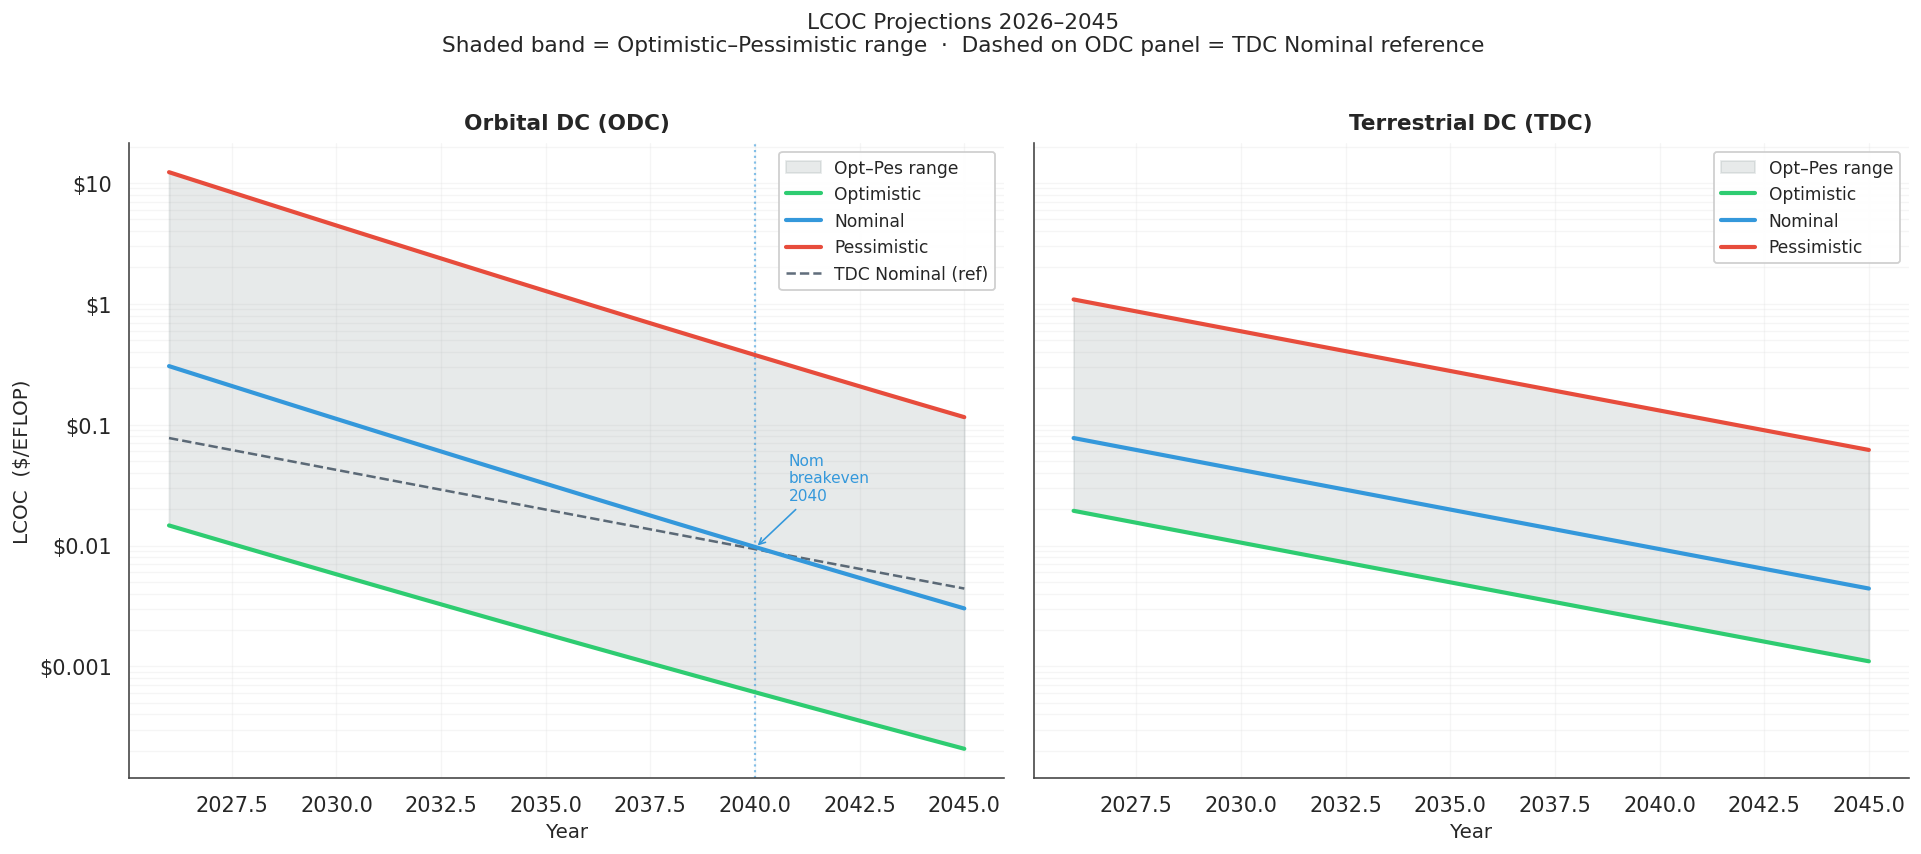

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)

odc_opt = lcoc_odc["Optimistic"]
odc_pes = lcoc_odc["Pessimistic"]
odc_nom = lcoc_odc["Nominal"]
tdc_opt = lcoc_tdc["Optimistic"]
tdc_pes = lcoc_tdc["Pessimistic"]
tdc_nom = lcoc_tdc["Nominal"]

for ax, data_dict, tdc_dict, title_suffix in [
    (axes[0], lcoc_odc, None,     "Orbital DC (ODC)"),
    (axes[1], lcoc_tdc, None,     "Terrestrial DC (TDC)"),
]:
    opt_arr = data_dict["Optimistic"]
    pes_arr = data_dict["Pessimistic"]
    nom_arr = data_dict["Nominal"]

    # Shaded uncertainty band (optimistic → pessimistic)
    ax.fill_between(
        years_calendar, opt_arr, pes_arr,
        alpha=0.18, color="#7f8c8d", label="Opt–Pes range", zorder=1
    )
    # Scenario lines
    for sname, arr in data_dict.items():
        ax.plot(years_calendar, arr,
                color=PALETTE[sname], linewidth=2.3, label=sname, zorder=3)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y:g}"))
    ax.set_xlabel("Year", fontsize=11)
    ax.set_title(title_suffix, fontsize=12, fontweight="bold", pad=8)
    ax.legend(fontsize=9.5, loc="upper right")
    ax.grid(True, which="both", alpha=0.30)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=False)

axes[0].set_ylabel("LCOC  ($/EFLOP)", fontsize=11)

# Cross-reference: add TDC nominal on the ODC panel (and vice versa)
axes[0].plot(years_calendar, tdc_nom, color=PALETTE["TDC"],
             linewidth=1.4, linestyle="--", alpha=0.75,
             label="TDC Nominal (ref)", zorder=2)
axes[0].legend(fontsize=9.5, loc="upper right")

# Annotate crossover on ODC panel
for sname in ["Optimistic", "Nominal"]:
    diff = lcoc_odc[sname] - lcoc_tdc[sname]
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    if len(sign_changes):
        ci = sign_changes[0]
        cy = years_calendar[ci]
        cv = (lcoc_odc[sname][ci] + lcoc_tdc[sname][ci]) / 2
        axes[0].axvline(cy, color=PALETTE[sname], linestyle=":", alpha=0.6, linewidth=1.2)
        axes[0].annotate(
            f"{sname[:3]}\nbreakeven\n{cy}",
            xy=(cy, cv), xytext=(cy + 0.8, cv * 2.5),
            fontsize=8.5, color=PALETTE[sname],
            arrowprops=dict(arrowstyle="->", color=PALETTE[sname], lw=0.9)
        )

fig.suptitle(
    "LCOC Projections 2026–2045\n"
    "Shaded band = Optimistic–Pessimistic range  ·  Dashed on ODC panel = TDC Nominal reference",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("/home/claude/fig_lcoc_time_bands.png", dpi=150, bbox_inches="tight")
plt.show()

### 7c. ODC / TDC Ratio Over Time

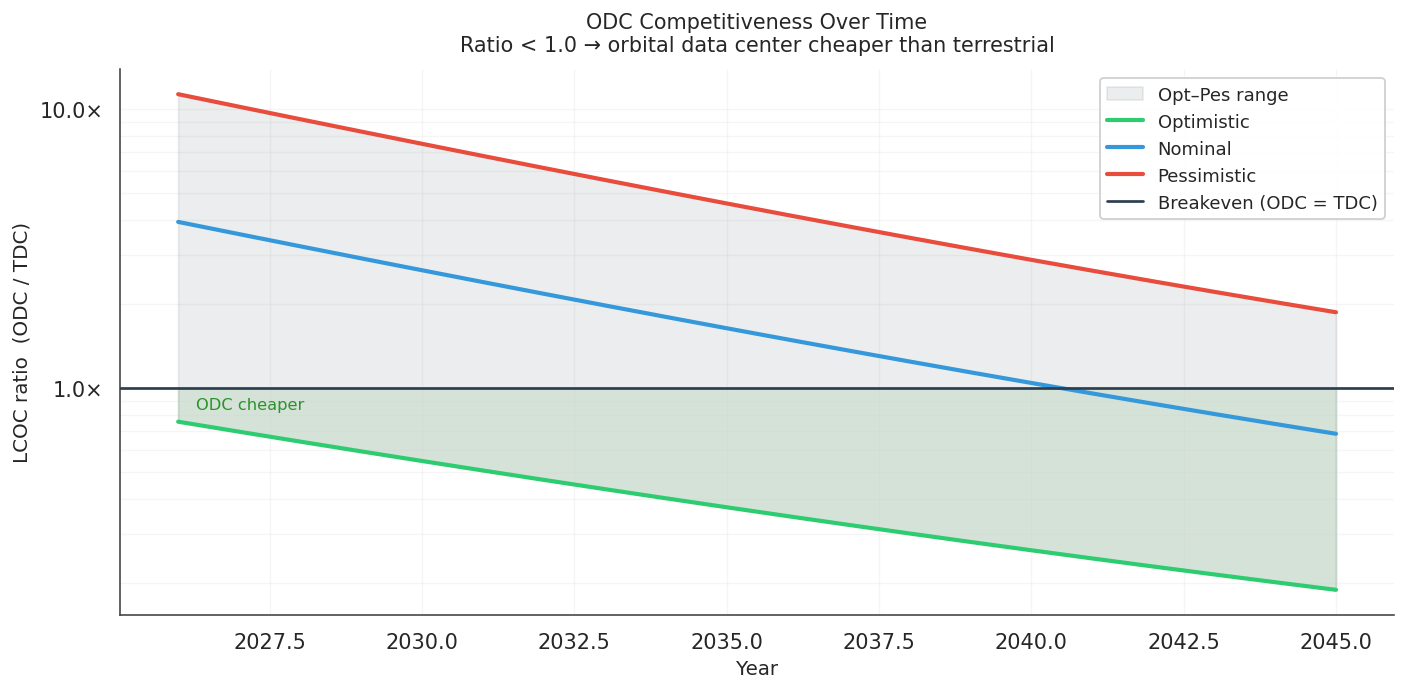

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ratios = {s.name: lcoc_odc[s.name] / lcoc_tdc[s.name] for s in SCENARIOS}

# Shaded band
ax.fill_between(
    years_calendar,
    ratios["Optimistic"], ratios["Pessimistic"],
    alpha=0.15, color="#7f8c8d", label="Opt–Pes range", zorder=1
)
for s in SCENARIOS:
    ax.plot(years_calendar, ratios[s.name],
            color=PALETTE[s.name], linewidth=2.3, label=s.name, zorder=3)

ax.axhline(1.0, color=PALETTE["TDC"], linewidth=1.5, linestyle="-",
           label="Breakeven (ODC = TDC)", zorder=4)
ax.fill_between(years_calendar,
                np.minimum(ratios["Optimistic"], 1),
                1, alpha=0.10, color="green", zorder=0)
ax.text(START_YEAR + 0.3, 0.93, "ODC cheaper", fontsize=9,
        color="green", alpha=0.8, va="top")

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}×"))
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("LCOC ratio  (ODC / TDC)", fontsize=11)
ax.set_title(
    "ODC Competitiveness Over Time\n"
    "Ratio < 1.0 → orbital data center cheaper than terrestrial",
    fontsize=11.5, pad=10
)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, which="both", alpha=0.30)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=False)
plt.tight_layout()
plt.savefig("/home/claude/fig_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

### 7d. Tornado Plot — Parameter Sensitivity (Nominal Scenario, 2026)

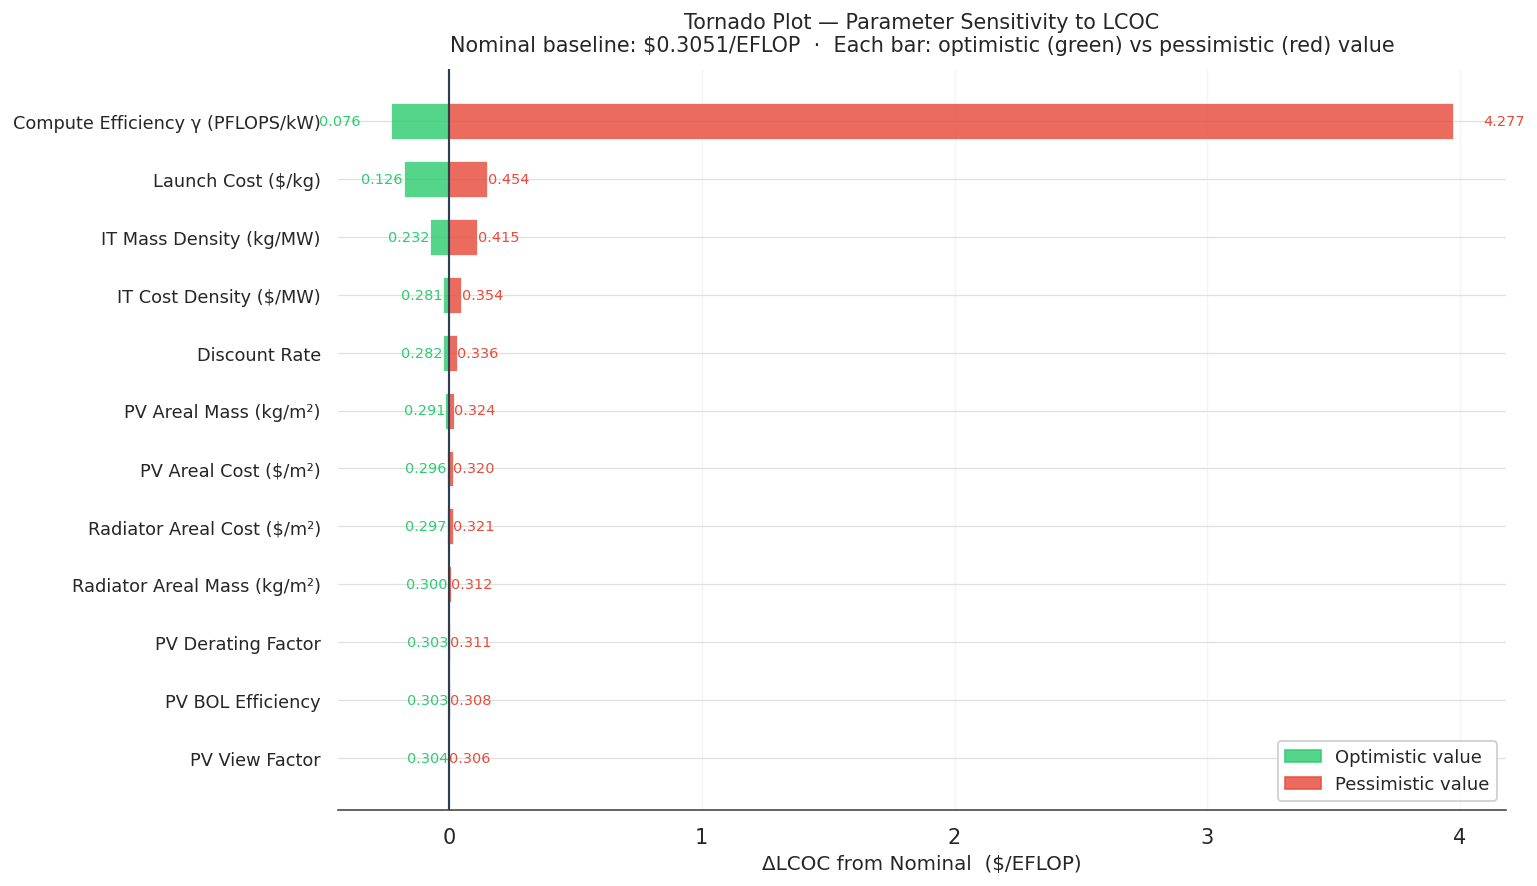

In [11]:
# ── Tornado: vary each parameter from optimistic → pessimistic,
#    keeping all others at nominal, and record ΔLCOC. ─────────────────────────

# Pretty labels for tornado plot
PARAM_LABELS = {
    "gamma_PFLOPS_per_kW":  "Compute Efficiency γ (PFLOPS/kW)",
    "launch_cost_per_kg":   "Launch Cost ($/kg)",
    "pv_eff_BOL":           "PV BOL Efficiency",
    "pv_derating":          "PV Derating Factor",
    "pv_areal_mass":        "PV Areal Mass (kg/m²)",
    "pv_areal_cost":        "PV Areal Cost ($/m²)",
    "rad_areal_mass":       "Radiator Areal Mass (kg/m²)",
    "rad_areal_cost":       "Radiator Areal Cost ($/m²)",
    "it_mass_density":      "IT Mass Density (kg/MW)",
    "it_cost_per_MW":       "IT Cost Density ($/MW)",
    "F_PV":                 "PV View Factor",
    "T_PV_C":               "PV Temperature (°C)",
    "alpha_solar_rad":      "Radiator Solar Absorptance",
    "eps_IR":               "Radiator IR Emissivity",
    "discount_rate":        "Discount Rate",
    "F_earth":              "Earth View Factor",
}

base_lcoc = results["Nominal"]["lcoc"]
tornado_rows = []

for param, (opt_val, nom_val, pes_val) in PARAM_TABLE.items():
    # Optimistic value of this param
    s_opt = replace(NOMINAL, **{param: opt_val})
    try:
        lcoc_opt = calculate_lcoc(s_opt)["lcoc"]
    except ValueError:
        lcoc_opt = np.nan

    # Pessimistic value of this param
    s_pes = replace(NOMINAL, **{param: pes_val})
    try:
        lcoc_pes = calculate_lcoc(s_pes)["lcoc"]
    except ValueError:
        lcoc_pes = np.nan

    delta_opt = lcoc_opt - base_lcoc   # negative = beneficial
    delta_pes = lcoc_pes - base_lcoc   # positive = detrimental
    swing     = abs(lcoc_pes - lcoc_opt)

    tornado_rows.append({
        "param":     param,
        "label":     PARAM_LABELS.get(param, param),
        "lcoc_opt":  lcoc_opt,
        "lcoc_pes":  lcoc_pes,
        "delta_opt": delta_opt,
        "delta_pes": delta_pes,
        "swing":     swing,
    })

# Sort by swing (total impact)
tornado_rows.sort(key=lambda r: r["swing"], reverse=False)   # ascending → largest at top
top_n = 12  # show top-N parameters
tornado_rows = tornado_rows[-top_n:]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

y_pos   = np.arange(len(tornado_rows))
labels  = [r["label"] for r in tornado_rows]

for i, row in enumerate(tornado_rows):
    lo = min(row["delta_opt"], row["delta_pes"])
    hi = max(row["delta_opt"], row["delta_pes"])

    # Bar to the left (improvement side)
    ax.barh(i, lo, left=0, height=0.62,
            color=PALETTE["Optimistic"], alpha=0.82, edgecolor="white", linewidth=0.5)
    # Bar to the right (degradation side)
    ax.barh(i, hi, left=0, height=0.62,
            color=PALETTE["Pessimistic"], alpha=0.82, edgecolor="white", linewidth=0.5)

    # Value annotations
    offset = max(abs(lo), abs(hi)) * 0.03
    if lo < 0:
        ax.text(lo - offset, i, f"{row['lcoc_opt']:.3f}",
                va="center", ha="right", fontsize=8, color=PALETTE["Optimistic"])
    if hi > 0:
        ax.text(hi + offset, i, f"{row['lcoc_pes']:.3f}",
                va="center", ha="left",  fontsize=8, color=PALETTE["Pessimistic"])

ax.axvline(0, color="#2c3e50", linewidth=1.2, zorder=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9.8)
ax.set_xlabel("ΔLCOC from Nominal  ($/EFLOP)", fontsize=11)
ax.set_title(
    "Tornado Plot — Parameter Sensitivity to LCOC\n"
    f"Nominal baseline: ${base_lcoc:.4f}/EFLOP  ·  Each bar: optimistic (green) vs pessimistic (red) value",
    fontsize=11.5, pad=10
)

legend_patches = [
    mpatches.Patch(color=PALETTE["Optimistic"], alpha=0.82, label="Optimistic value"),
    mpatches.Patch(color=PALETTE["Pessimistic"], alpha=0.82, label="Pessimistic value"),
]
ax.legend(handles=legend_patches, fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.35, zorder=0)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.savefig("/home/claude/fig_tornado.png", dpi=150, bbox_inches="tight")
plt.show()

### 7e. LCOC vs Launch Cost — Baseline Sweep with TDC Reference

In [12]:
# ── Sweep launch cost from ~$50/kg (Starship floor) to $5,000/kg ─────────────
launch_costs = np.logspace(np.log10(50), np.log10(5000), 120)  # $/kg

fig, ax = plt.subplots(figsize=(12, 6.5))

# --- ODC LCOC sweep for each scenario (varying ONLY launch cost) ---
for s in SCENARIOS:
    lcoc_sweep = []
    for lc in launch_costs:
        s_swept = replace(s, launch_cost_per_kg=lc)
        lcoc_sweep.append(calculate_lcoc(s_swept)["lcoc"])
    lcoc_sweep = np.array(lcoc_sweep)

    ax.plot(launch_costs, lcoc_sweep,
            color=PALETTE[s.name], linewidth=2.3, label=f"ODC {s.name}", zorder=3)

    # Mark the scenario's own nominal launch cost
    base_lc   = s.launch_cost_per_kg
    base_lcoc_val = results[s.name]["lcoc"]
    ax.scatter([base_lc], [base_lcoc_val], color=PALETTE[s.name],
               s=80, zorder=6, edgecolors="white", linewidths=1.2)

# --- TDC reference lines (horizontal, one per scenario γ) ---
tdc_nom_val = terr["Nominal"]
ax.axhline(tdc_nom_val, color=PALETTE["TDC"], linewidth=2.0,
           linestyle="--", zorder=4, label=f"TDC Nominal  (${tdc_nom_val:.3f}/EFLOP)")

# Shade where ODC Nominal < TDC Nominal
nom_sweep = np.array([calculate_lcoc(replace(NOMINAL, launch_cost_per_kg=lc))["lcoc"]
                      for lc in launch_costs])
ax.fill_between(
    launch_costs, nom_sweep, tdc_nom_val,
    where=(nom_sweep < tdc_nom_val),
    alpha=0.12, color=PALETTE["Optimistic"],
    label="ODC Nominal cheaper than TDC", zorder=1
)

# Annotate scenario launch cost markers
for s in SCENARIOS:
    ax.axvline(s.launch_cost_per_kg, color=PALETTE[s.name],
               linewidth=0.8, linestyle=":", alpha=0.55, zorder=2)
    ax.text(s.launch_cost_per_kg, ax.get_ylim()[0] if ax.get_yscale() == "log" else 0,
            f"  {s.name[:3]}\n  ${s.launch_cost_per_kg:,.0f}/kg",
            fontsize=7.5, color=PALETTE[s.name], va="bottom", rotation=0)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y:g}"))
ax.set_xlabel("Launch Cost  ($/kg)", fontsize=11)
ax.set_ylabel("LCOC  ($/EFLOP)", fontsize=11)
ax.set_title(
    "ODC LCOC vs Launch Cost  ·  2026 Baseline Parameters\n"
    "Circles = scenario's own launch cost  ·  Dashed = TDC Nominal reference  ·  "
    "Green fill = ODC Nominal cheaper than TDC",
    fontsize=11, pad=10
)
ax.legend(fontsize=9.5, loc="upper left", ncol=2)
ax.grid(True, which="both", alpha=0.30)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=False)
plt.tight_layout()
plt.savefig("/home/claude/fig_lcoc_vs_launch.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_589/1803288183.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


---
## 8. Summary Table

In [13]:
print("=" * 78)
print("SUMMARY: Orbital vs Terrestrial DC LCOC (2026–2045 projection)")
print("=" * 78)
for s in SCENARIOS:
    print(f"\n--- {s.name}  (γ₀ = {s.gamma_PFLOPS_per_kW} PFLOPS/kW) ---")
    for label, idx in [("2026", 0), ("2035", 9), ("2045", 19)]:
        odc = lcoc_odc[s.name][idx]
        tdc = lcoc_tdc[s.name][idx]
        verdict = "ODC wins ✓" if odc < tdc else "TDC wins"
        print(f"  {label}:  ODC ${odc:>8.4f}/EFLOP  |"
              f"  TDC ${tdc:>8.4f}/EFLOP  |"
              f"  ratio {odc/tdc:>5.2f}×  ({verdict})")
print("\n" + "=" * 78)
print("Key drivers (tornado plot, top 3):")
for row in reversed(tornado_rows[-3:]):
    print(f"  {row['label']:<45s}  swing = {row['swing']:.4f} $/EFLOP")

SUMMARY: Orbital vs Terrestrial DC LCOC (2026–2045 projection)

--- Optimistic  (γ₀ = 6.0 PFLOPS/kW) ---
  2026:  ODC $  0.0147/EFLOP  |  TDC $  0.0194/EFLOP  |  ratio  0.76×  (ODC wins ✓)
  2035:  ODC $  0.0019/EFLOP  |  TDC $  0.0050/EFLOP  |  ratio  0.37×  (ODC wins ✓)
  2045:  ODC $  0.0002/EFLOP  |  TDC $  0.0011/EFLOP  |  ratio  0.19×  (ODC wins ✓)

--- Nominal  (γ₀ = 1.5 PFLOPS/kW) ---
  2026:  ODC $  0.3051/EFLOP  |  TDC $  0.0775/EFLOP  |  ratio  3.94×  (TDC wins)
  2035:  ODC $  0.0325/EFLOP  |  TDC $  0.0198/EFLOP  |  ratio  1.64×  (TDC wins)
  2045:  ODC $  0.0030/EFLOP  |  TDC $  0.0044/EFLOP  |  ratio  0.68×  (ODC wins ✓)

--- Pessimistic  (γ₀ = 0.107 PFLOPS/kW) ---
  2026:  ODC $ 12.2727/EFLOP  |  TDC $  1.0863/EFLOP  |  ratio 11.30×  (TDC wins)
  2035:  ODC $  1.2750/EFLOP  |  TDC $  0.2781/EFLOP  |  ratio  4.59×  (TDC wins)
  2045:  ODC $  0.1153/EFLOP  |  TDC $  0.0618/EFLOP  |  ratio  1.87×  (TDC wins)

Key drivers (tornado plot, top 3):
  Compute Efficiency γ (PFLOP